In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader


import torchvision
from torchvision import transforms, datasets, models
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

import os

import random
import numpy as np
import pandas as pd

from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from tqdm.auto import tqdm

import warnings
warnings.filterwarnings("ignore")

print("=" * 60)
print("🌹 RoseNet: Rose Color Classification")
print(f"PyTorch Version     : {torch.__version__}")
print(f"Torchvision Version : {torchvision.__version__}")
print(f"GPU Available       : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Name            : {torch.cuda.get_device_name(0)}")

print("=" * 60)

🌹 RoseNet: Rose Color Classification
PyTorch Version     : 2.10.0+cu128
Torchvision Version : 0.25.0+cu128
GPU Available       : True
GPU Name            : Tesla T4


In [2]:
SEED = 42

IMAGE_SIZE = 224
BATCH_SIZE = 32

EPOCHS = 20

LEARNING_RATE = 1e-4

NUM_CLASSES = 4

NUM_WORKERS = 2

In [3]:
DATASET_DIR = "/kaggle/input/datasets/maulikgajera/rose-color-classification-dataset/Rose Dataset"

# Save Model
MODEL_PATH = "best_efficientnet_b0.pth"

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
def set_seed(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

In [5]:
image_paths = []
labels = []

# Class Names
classes = sorted(os.listdir(DATASET_DIR))

print("=" * 60)
print("Classes Found")
print("=" * 60)

for cls in classes:
    print(cls)

print("=" * 60)

# Read all images
for cls in classes:

    class_path = os.path.join(DATASET_DIR, cls)

    if not os.path.isdir(class_path):
        continue

    for img_name in os.listdir(class_path):

        img_path = os.path.join(class_path, img_name)

        if img_name.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):
            image_paths.append(img_path)
            labels.append(cls)


df = pd.DataFrame({
    "image_path": image_paths,
    "label": labels
})

print(f"Total Images : {len(df)}")

print("\nFirst 5 Samples")
display(df.head())

Classes Found
Pink
Red
White
Yellow
Total Images : 3000

First 5 Samples


,image_path,label
0,/kaggle/input/datasets/maulikgajera/rose-color...,Pink
1,/kaggle/input/datasets/maulikgajera/rose-color...,Pink
2,/kaggle/input/datasets/maulikgajera/rose-color...,Pink
3,/kaggle/input/datasets/maulikgajera/rose-color...,Pink
4,/kaggle/input/datasets/maulikgajera/rose-color...,Pink


label
Pink       900
Red       1200
White      400
Yellow     500
Name: count, dtype: int64

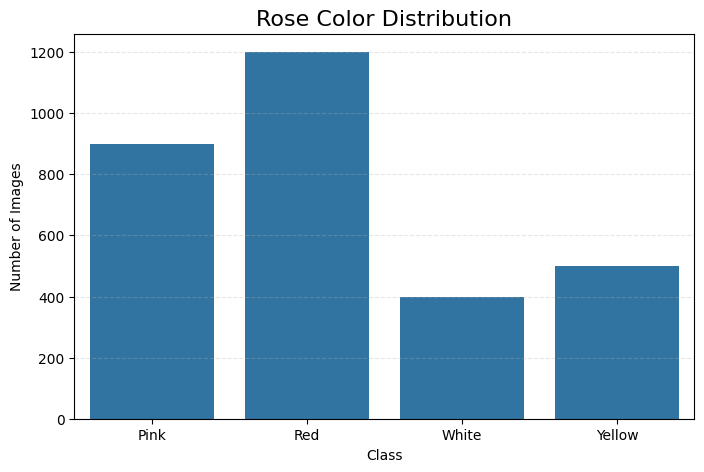

In [6]:
class_counts = df["label"].value_counts().sort_index()

display(class_counts)

plt.figure(figsize=(8,5))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values
)

plt.title("Rose Color Distribution", fontsize=16)

plt.xlabel("Class")

plt.ylabel("Number of Images")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

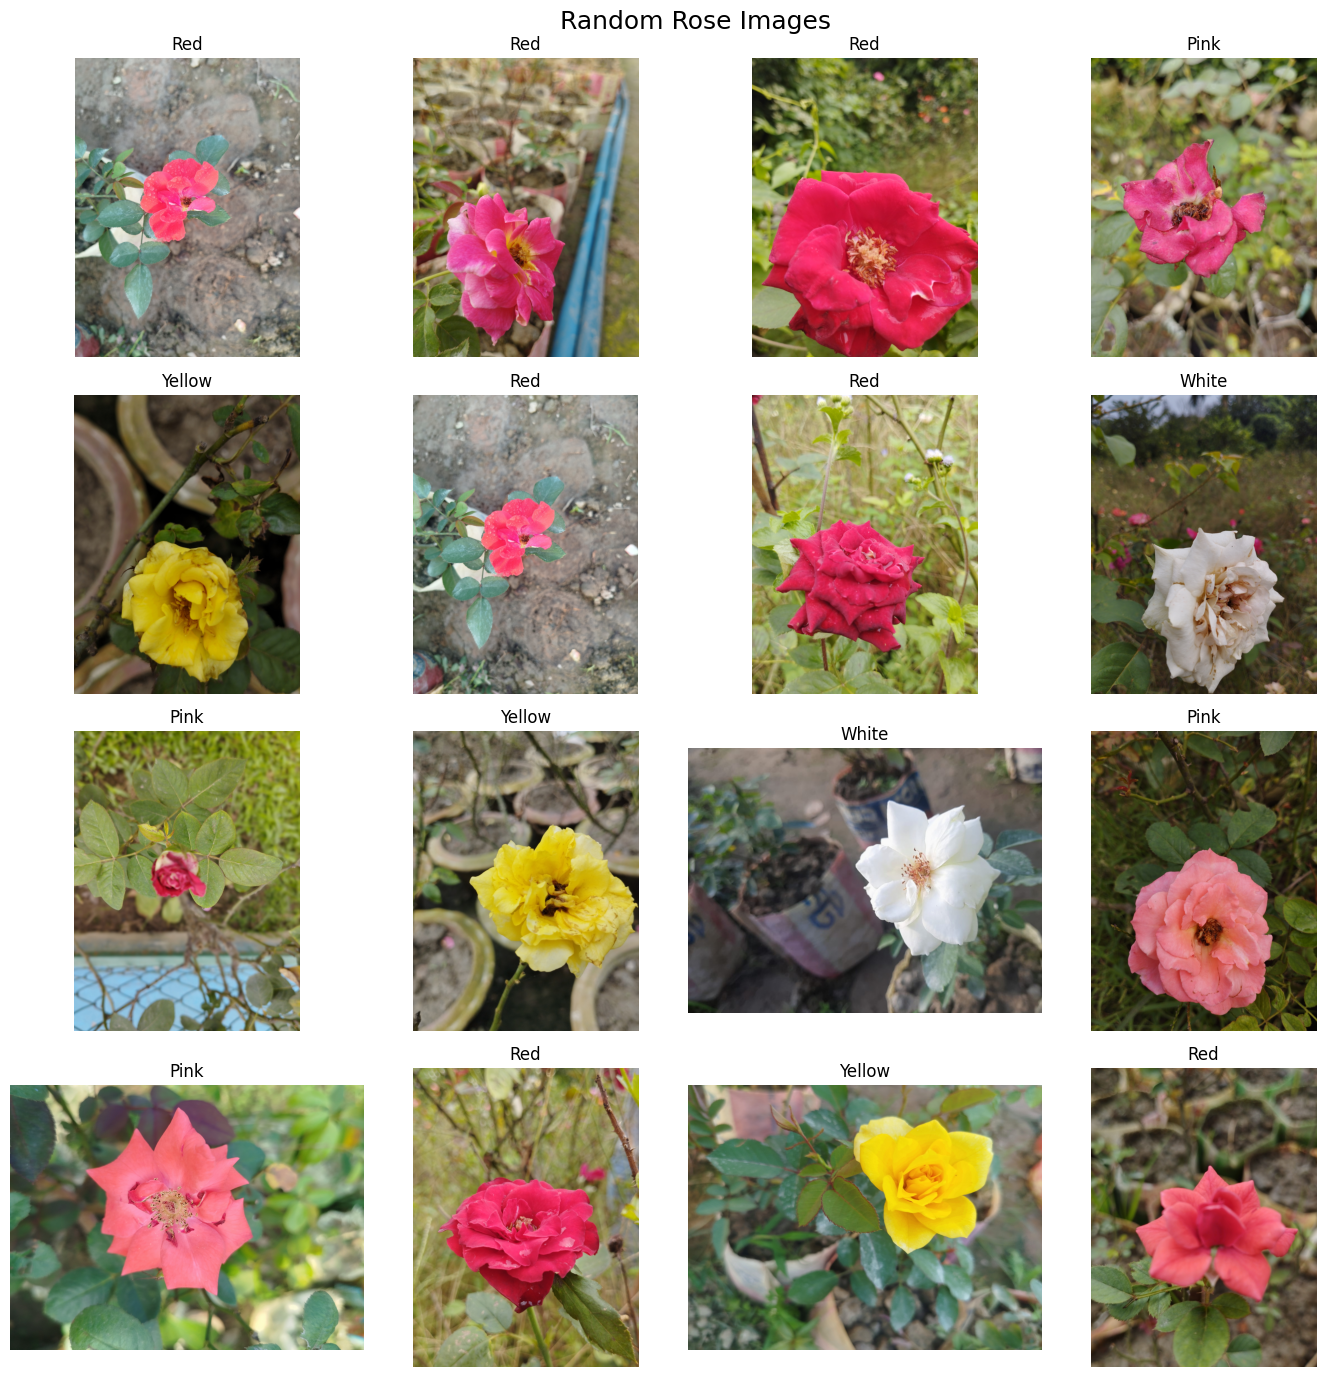

In [7]:
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
axes = axes.flatten()

# Randomly sample 16 images
sample_df = df.sample(16, random_state=SEED).reset_index(drop=True)

for idx, ax in enumerate(axes):

    img_path = sample_df.loc[idx, "image_path"]
    label = sample_df.loc[idx, "label"]

    image = Image.open(img_path).convert("RGB")

    ax.imshow(image)
    ax.set_title(label, fontsize=12)
    ax.axis("off")

plt.suptitle("Random Rose Images", fontsize=18)
plt.tight_layout()

plt.show()

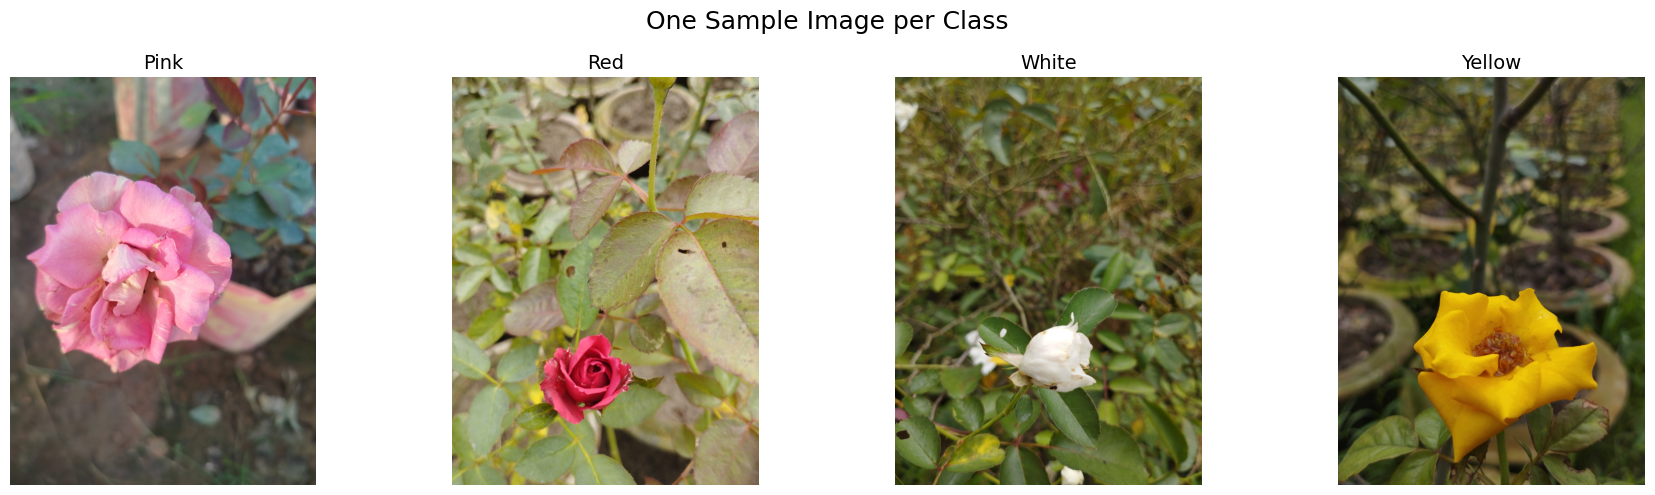

In [8]:
fig, axes = plt.subplots(1, len(classes), figsize=(18, 5))

for ax, cls in zip(axes, classes):

    sample = df[df["label"] == cls].sample(1, random_state=SEED)

    img = Image.open(sample.iloc[0]["image_path"]).convert("RGB")

    ax.imshow(img)
    ax.set_title(cls, fontsize=14)
    ax.axis("off")

plt.suptitle("One Sample Image per Class", fontsize=18)

plt.tight_layout()

plt.show()

In [9]:
# First Split: Train (70%) and Temp (30%)
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED,
    shuffle=True
)

# Second Split: Validation (15%) and Test (15%)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED,
    shuffle=True
)


# Reset Index
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

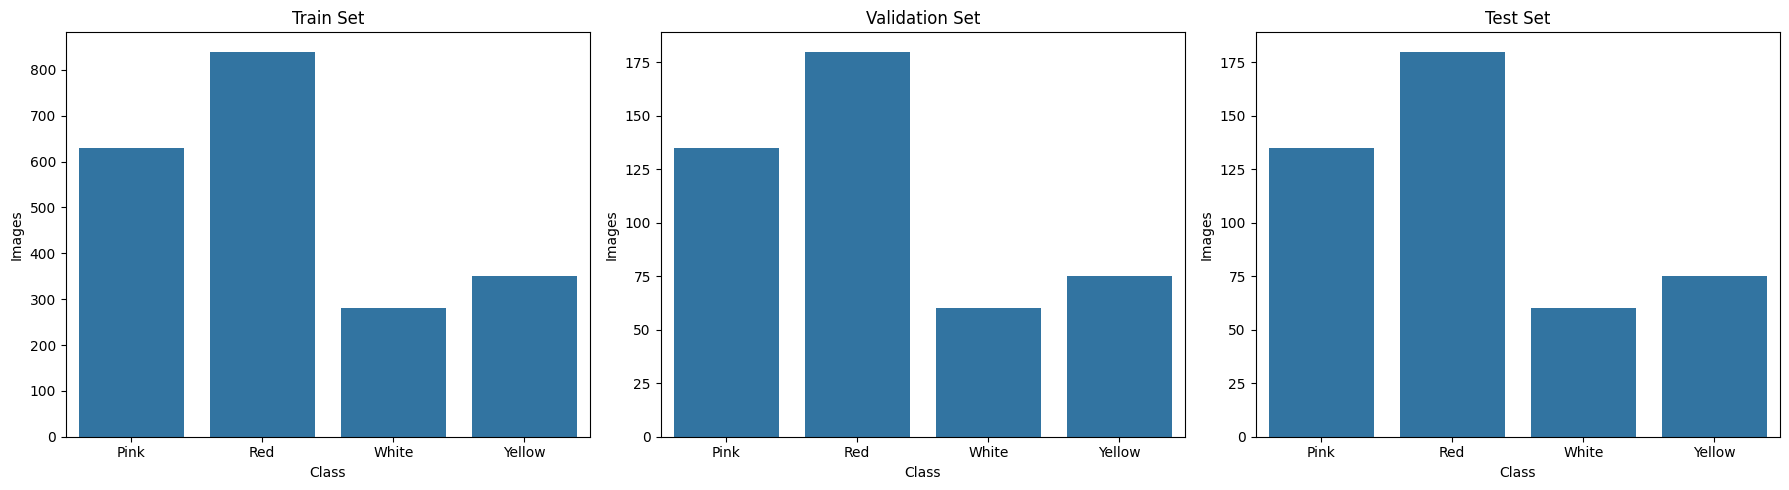

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

datasets = {
    "Train": train_df,
    "Validation": val_df,
    "Test": test_df
}

for ax, (name, data) in zip(axes, datasets.items()):

    counts = data["label"].value_counts().sort_index()

    sns.barplot(x=counts.index, y=counts.values, ax=ax)

    ax.set_title(f"{name} Set")
    ax.set_xlabel("Class")
    ax.set_ylabel("Images")

plt.tight_layout()
plt.show()

In [11]:
from torchvision import transforms

# ImageNet Mean and Standard Deviation
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Training Transform
train_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomVerticalFlip(p=0.2),

    transforms.RandomRotation(degrees=20),

    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),

    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),

    transforms.ToTensor(),

    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

])

In [12]:
# Validation / Test Transform
test_transform = transforms.Compose([

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(),

    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)

])

In [13]:
from torch.utils.data import Dataset
from PIL import Image

class RoseDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.dataframe = dataframe
        self.transform = transform

        # Label Encoding
        self.class_to_idx = {"Pink": 0, "Red": 1, "White": 2, "Yellow": 3}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        img_path = self.dataframe.iloc[index]["image_path"]

        label = self.dataframe.iloc[index]["label"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = self.class_to_idx[label]

        return image, label

In [14]:
train_dataset = RoseDataset(train_df, transform=train_transform)

val_dataset = RoseDataset(val_df, transform=test_transform)

test_dataset = RoseDataset(test_df, transform=test_transform)

In [15]:
image, label = train_dataset[0]

print("Image Shape :", image.shape)
print("Label Index :", label)

print("\nClass Mapping")

print(train_dataset.class_to_idx)

Image Shape : torch.Size([3, 224, 224])
Label Index : 1

Class Mapping
{'Pink': 0, 'Red': 1, 'White': 2, 'Yellow': 3}


In [16]:
train_loader = DataLoader(train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("DataLoaders Created Successfully!")

✅ DataLoaders Created Successfully!


In [17]:
images, labels = next(iter(train_loader))

print("Images Shape :", images.shape)
print("Labels Shape :", labels.shape)

print("\nFirst 10 Labels:")
print(labels[:10])

Images Shape : torch.Size([32, 3, 224, 224])
Labels Shape : torch.Size([32])

First 10 Labels:
tensor([2, 1, 3, 0, 1, 0, 0, 3, 0, 0])


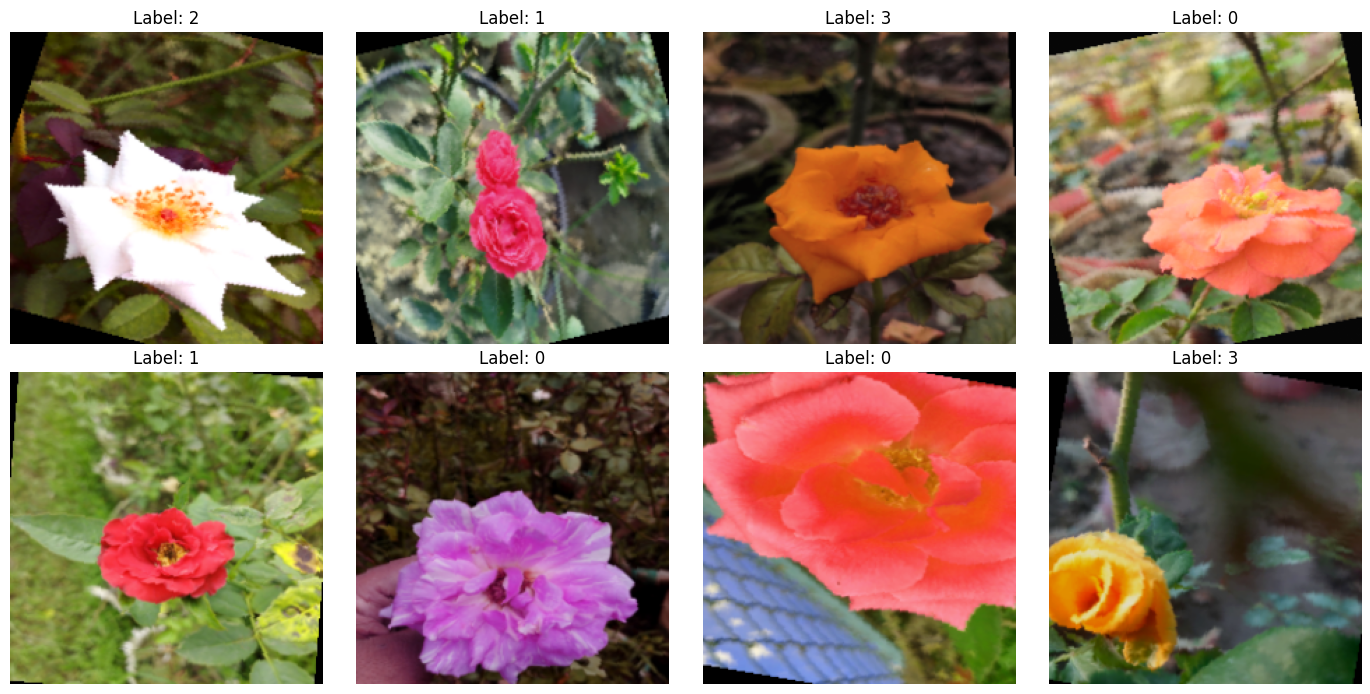

In [18]:
mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i in range(8):

    image = images[i].cpu() * std + mean
    image = image.clamp(0, 1)

    axes[i].imshow(image.permute(1, 2, 0))
    axes[i].set_title(f"Label: {labels[i].item()}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [19]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch.nn as nn

# Load pretrained weights
weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(weights=weights)

# Replace classifier
in_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(
    in_features,
    NUM_CLASSES
)

# Move model to device
model = model.to(DEVICE)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 140MB/s] 


In [20]:
total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)


In [21]:
images, labels = next(iter(train_loader))

images = images.to(DEVICE)

with torch.no_grad():

    outputs = model(images)

print("Input Shape :", images.shape)
print("Output Shape:", outputs.shape)

Input Shape : torch.Size([32, 3, 224, 224])
Output Shape: torch.Size([32, 4])


In [22]:
import torch.optim as optim

# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)

# Learning Rate Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)


In [23]:
best_val_loss = float("inf")
best_val_accuracy = 0.0

early_stop_patience = 5
early_stop_counter = 0

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

print("Training history initialized.")

Training history initialized.


In [24]:
for epoch in range(EPOCHS):

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print("-" * 60)
    # Training
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    train_bar = tqdm(train_loader, leave=False)

    for images, labels in train_bar:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        train_total += labels.size(0)

        train_correct += (preds == labels).sum().item()

        train_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    train_loss /= len(train_loader)

    train_acc = train_correct / train_total

    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        val_bar = tqdm(val_loader, leave=False)

        for images, labels in val_bar:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)

            val_total += labels.size(0)

            val_correct += (preds == labels).sum().item()

            val_bar.set_postfix(
                loss=f"{loss.item():.4f}"
            )

    val_loss /= len(val_loader)

    val_acc = val_correct / val_total

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        best_val_accuracy = val_acc

        torch.save(model.state_dict(), MODEL_PATH)

        early_stop_counter = 0

        print("Best model saved!")

    else:

        early_stop_counter += 1

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f}"
    )

    print(
        f"Val Loss:   {val_loss:.4f} | "
        f"Val Acc:   {val_acc:.4f}"
    )

    print(
        f"Learning Rate: "
        f"{optimizer.param_groups[0]['lr']:.6f}"
    )

    if early_stop_counter >= early_stop_patience:

        print("\nEarly stopping triggered!")

        break

print("\nTraining Finished Successfully!")


Epoch [1/20]
------------------------------------------------------------


  0%|          | 0/66 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

✅ Best model saved!
Train Loss: 0.9172 | Train Acc: 0.7000
Val Loss:   0.3354 | Val Acc:   0.9156
Learning Rate: 0.000100

Epoch [2/20]
------------------------------------------------------------


  0%|          | 0/66 [00:00<?, ?it/s]

...

  0%|          | 0/15 [00:00<?, ?it/s]

✅ Best model saved!
Train Loss: 0.0183 | Train Acc: 0.9933
Val Loss:   0.0003 | Val Acc:   1.0000
Learning Rate: 0.000100

Epoch [20/20]
------------------------------------------------------------


  0%|          | 0/66 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

Train Loss: 0.0084 | Train Acc: 0.9981
Val Loss:   0.0058 | Val Acc:   1.0000
Learning Rate: 0.000100

Training Finished Successfully!


In [25]:
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()


all_predictions = []
all_labels = []

test_loss = 0.0
correct = 0
total = 0

with torch.no_grad():

    test_bar = tqdm(test_loader)

    for images, labels in test_bar:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()

        total += labels.size(0)

        all_predictions.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss /= len(test_loader)

test_accuracy = correct / total

print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

  0%|          | 0/15 [00:00<?, ?it/s]


Test Loss     : 0.0002
Test Accuracy : 1.0000


In [26]:
idx_to_class = {
    0: "Pink",
    1: "Red",
    2: "White",
    3: "Yellow"
}

target_names = [idx_to_class[i] for i in range(NUM_CLASSES)]

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=target_names,
        digits=4
    )
)

              precision    recall  f1-score   support

        Pink     1.0000    1.0000    1.0000       135
         Red     1.0000    1.0000    1.0000       180
       White     1.0000    1.0000    1.0000        60
      Yellow     1.0000    1.0000    1.0000        75

    accuracy                         1.0000       450
   macro avg     1.0000    1.0000    1.0000       450
weighted avg     1.0000    1.0000    1.0000       450



In [27]:
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(f"Overall Accuracy : {accuracy*100:.2f}%")

Overall Accuracy : 100.00%


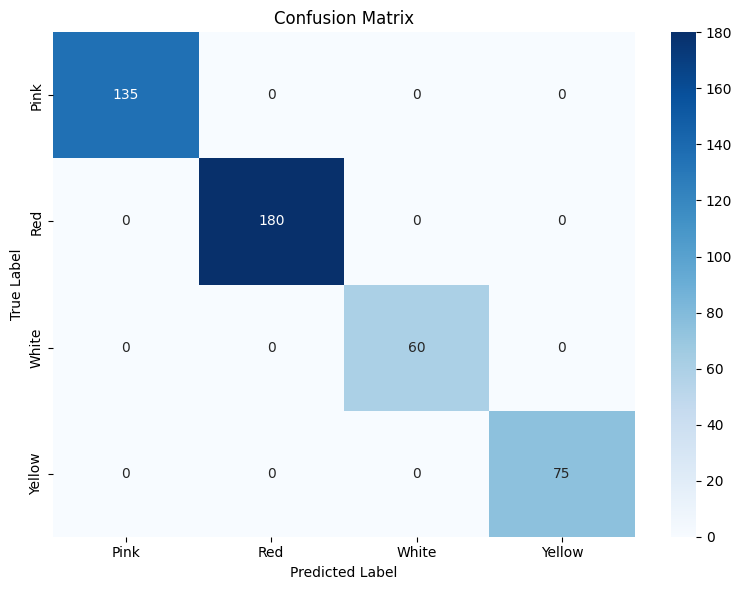

In [ ]:
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

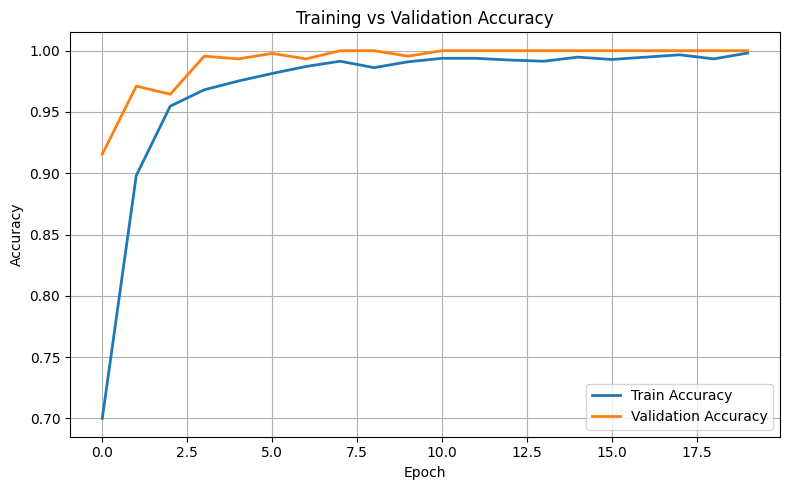

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history["train_accuracy"],
    label="Train Accuracy",
    linewidth=2
)

plt.plot(
    history["val_accuracy"],
    label="Validation Accuracy",
    linewidth=2
)

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

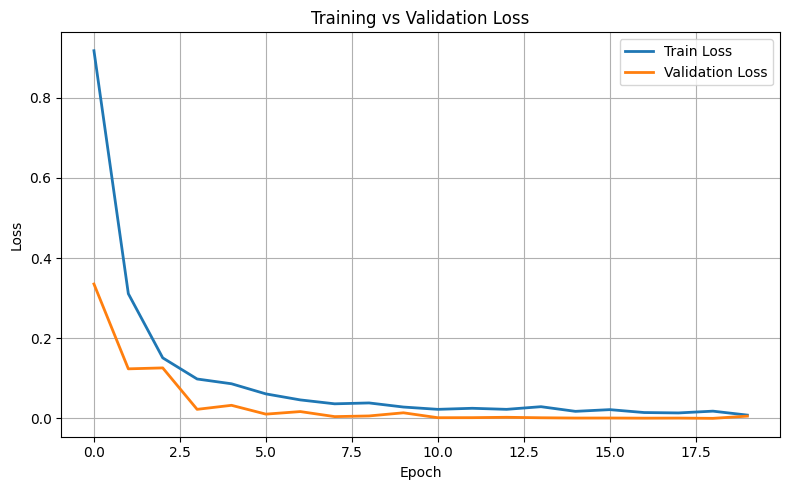

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history["train_loss"],
    label="Train Loss",
    linewidth=2
)

plt.plot(
    history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

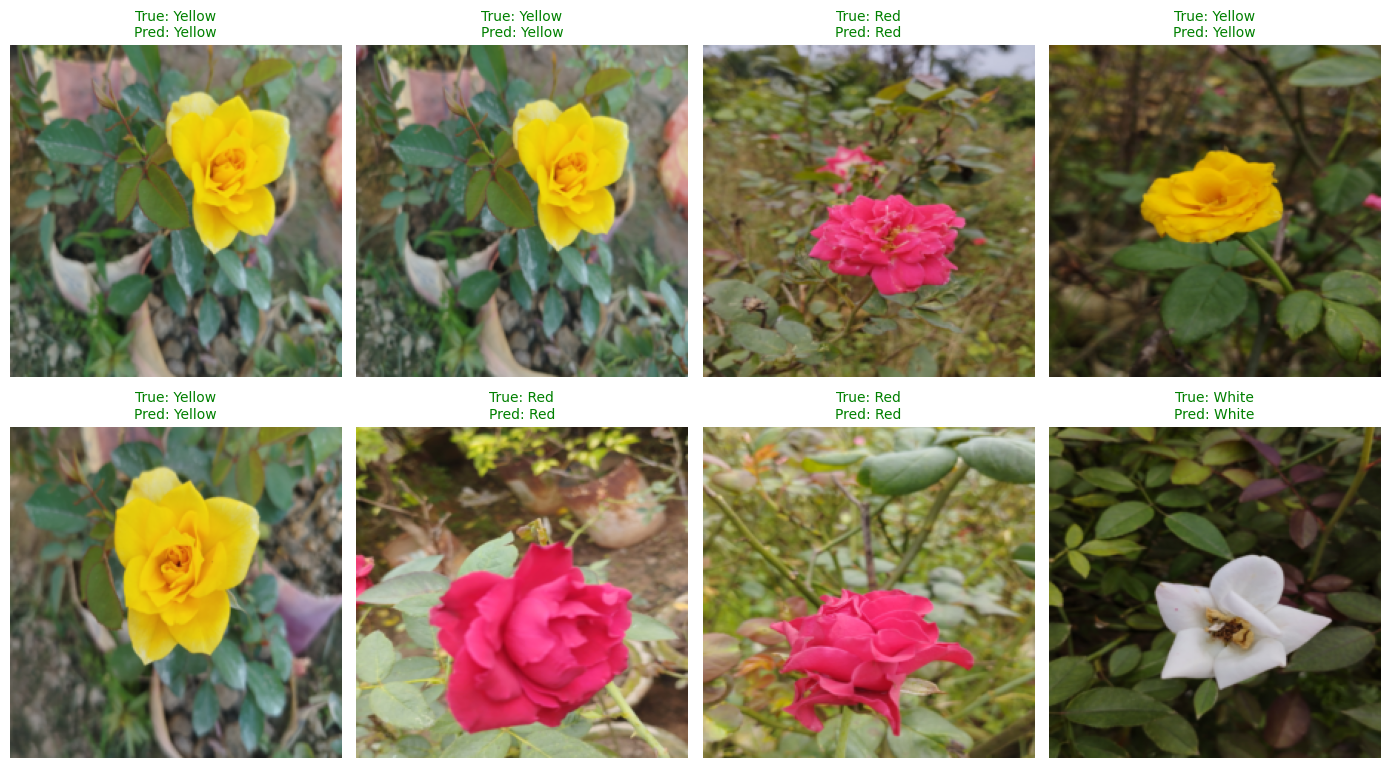

In [ ]:
idx_to_class = {
    0: "Pink",
    1: "Red",
    2: "White",
    3: "Yellow"
}

images, labels = next(iter(test_loader))

images = images.to(DEVICE)

model.eval()

with torch.no_grad():

    outputs = model(images)

    _, preds = torch.max(outputs, 1)

images = images.cpu()

mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 8))
axes = axes.flatten()

for i in range(8):

    image = images[i] * std + mean
    image = image.clamp(0, 1)

    axes[i].imshow(image.permute(1, 2, 0))

    true_label = idx_to_class[labels[i].item()]
    pred_label = idx_to_class[preds[i].item()]

    color = "green" if true_label == pred_label else "red"

    axes[i].set_title(
        f"True: {true_label}\nPred: {pred_label}",
        color=color,
        fontsize=10
    )

    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
print("=" * 60)
print("Rose Color Classification Completed Successfully!")
print("=" * 60)

print(f"Model           : EfficientNet-B0")
print(f"Image Size      : {IMAGE_SIZE} x {IMAGE_SIZE}")
print(f"Number of Classes : {NUM_CLASSES}")
print(f"Epochs          : {len(history['train_loss'])}")
print(f"Best Validation Accuracy : {best_val_accuracy:.4f}")
print(f"Test Accuracy   : {test_accuracy:.4f}")

print("=" * 60)

🌹 Rose Color Classification Completed Successfully!
Model           : EfficientNet-B0
Image Size      : 224 x 224
Number of Classes : 4
Epochs          : 20
Best Validation Accuracy : 1.0000
Test Accuracy   : 1.0000
